# Results


In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.insert(0, '..')

import numpy as np, pandas as pd

from finetuning import config as C, data as D, metrics as M
from finetuning import calibration as CAL, ood as OOD, plots as P

pd.set_option('display.width', 160)
MODEL = 'bert'


In [2]:
def load(split):
    d = np.load(C.RESULTS / f'{MODEL}_{split}.npz')
    return d['logits'], d['embeddings'], d['labels']

test_lg, test_em, test_y = load('test')
ood_lg,  ood_em,  ood_y  = load('ood')
val_lg,  val_em,  val_y  = load('val')
cal_lg,  cal_em,  cal_y  = load('cal')
fit_lg,  fit_em,  fit_y  = load('fit')

T = CAL.fit_temperature(cal_lg, cal_y)
THRESHOLD = CAL.pick_threshold(val_lg, val_y, T)
print(f'temperature {T:.4f} (fit on cal)   threshold {THRESHOLD:.2f} (chosen on val)')

test_p = CAL.positive_prob(test_lg, T)
ood_p  = CAL.positive_prob(ood_lg, T)


temperature 1.4469 (fit on cal)   threshold 0.35 (chosen on val)


## In-domain

Held-out 20% of the composite dataset.

`all-positive baseline` is a constant classifier that answers *claim* for every input
without reading it. On a balanced split it scores poorly, so it looks harmless here.


In [3]:
M.table(test_y, {'bert (finetuned)': (test_p >= THRESHOLD).astype(int)})


,accuracy,precision,recall,f1,n,pred_positive_rate
bert (finetuned),0.9088,0.9185,0.8829,0.9004,2600.0,0.4485
all-positive baseline,0.4665,0.4665,1.0000,0.6362,2600.0,1.0000


## Out-of-domain

The CheckThat tweets, which the model never saw. 63% of them are claims, so the constant
classifier gets 0.63 accuracy and 0.77 F1 for free.

Compare the model's row to the baseline row before reading the F1 as a result.


In [4]:
M.table(ood_y, {'bert (finetuned)': (ood_p >= THRESHOLD).astype(int)})


,accuracy,precision,recall,f1,n,pred_positive_rate
bert (finetuned),0.6378,0.6356,0.9965,0.7761,911.0,0.9879
all-positive baseline,0.6301,0.6301,1.0000,0.7731,911.0,1.0000


### Threshold sensitivity

Training data is 47.8% positive, the tweets are 63%. If the drop out of domain were caused
by that prior mismatch, moving the decision boundary would recover some of it.

This sweeps the threshold from 0.05 to 0.95 to check.


,accuracy,precision,recall,f1,n,pred_positive_rate
threshold,,,,,,
0.05,0.6301,0.6301,1.0000,0.7731,911,1.0000
0.10,0.6356,0.6336,1.0000,0.7757,911,0.9945
0.15,0.6367,0.6343,1.0000,0.7762,911,0.9934
0.20,0.6367,0.6343,1.0000,0.7762,911,0.9934
0.25,0.6356,0.6341,0.9965,0.7751,911,0.9901
0.30,0.6367,0.6349,0.9965,0.7756,911,0.9890
0.35,0.6378,0.6356,0.9965,0.7761,911,0.9879
0.40,0.6378,0.6356,0.9965,0.7761,911,0.9879
0.45,0.6400,0.6370,0.9965,0.7772,911,0.9857


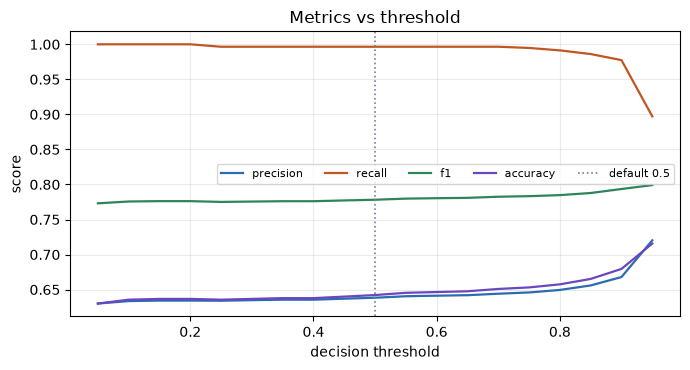

In [5]:
sweep = M.sweep_threshold(ood_y, ood_p)
P.threshold_sweep(sweep, name='ood_threshold_sweep');
sweep


## Calibration

The API serves the calibrated probability, not the raw softmax. Temperature is fitted on
the calibration split, then the decision threshold is chosen on validation using those
already-calibrated probabilities - the order matters, since a threshold picked on raw
scores lands somewhere else once the scores are rescaled.

Test is used for neither.

ECE is the mean gap between claimed confidence and observed accuracy; Brier is the mean
squared error of the probability itself.


### Before and after

Four options, all fitted on the calibration split only:

- **uncalibrated** - the raw softmax, what most people return as a confidence
- **temperature** - one parameter, divides the logits. Cannot change any prediction at
  threshold 0.5, since the scale cancels; it only makes the number honest
- **platt** - two parameters, rescales *and* shifts, so it can move the boundary
- **isotonic** - non-parametric monotonic fit, most flexible, most prone to overfitting


In [6]:
CAL.compare(cal_lg, cal_y, {
    'validation': (val_lg, val_y),
    'in-domain (test)': (test_lg, test_y),
    'out-of-domain (tweets)': (ood_lg, ood_y),
})


ece   brier  mean_confidence  accuracy
split                  method                                                          
validation             uncalibrated           0.0525  0.0784           0.9496    0.8971
                       temperature (T=1.447)  0.0441  0.0746           0.9109    0.8971
                       platt                  0.0254  0.0741           0.9108    0.9029
                       isotonic               0.0284  0.0757           0.9060    0.8933
in-domain (test)       uncalibrated           0.0495  0.0709           0.9580    0.9108
                       temperature (T=1.447)  0.0389  0.0665           0.9194    0.9108
                       platt                  0.0392  0.0661           0.9185    0.9108
                       isotonic               0.0206  0.0662           0.9165    0.9085
out-of-domain (tweets) uncalibrated           0.3409  0.3391           0.9814    0.6422
                       temperature (T=1.447)  0.3112  0.3158           0.9534    0.6422
                       platt                  0.3277  0.3270           0.9655    0.6400
                       isotonic               0.3363  0.3298           0.9734    0.6509

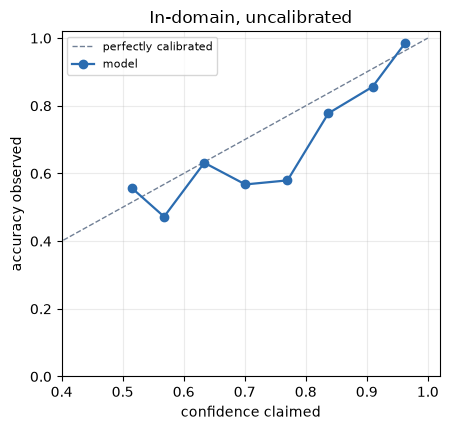

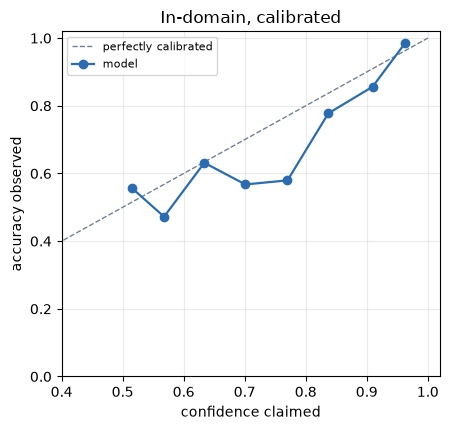

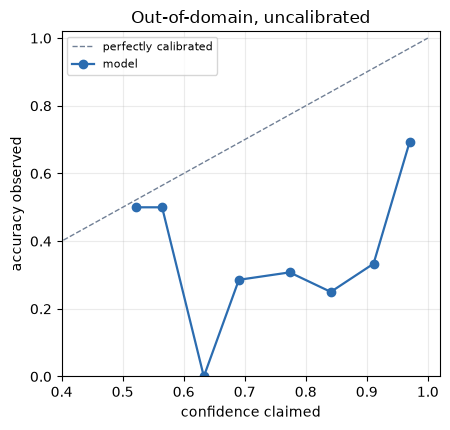

In [7]:
P.reliability(test_y, test_p, title='In-domain, uncalibrated', name='reliability_test_raw');
P.reliability(test_y, CAL.positive_prob(test_lg, T), title='In-domain, calibrated',
              name='reliability_test_cal');
P.reliability(ood_y, ood_p, title='Out-of-domain, uncalibrated', name='reliability_ood_raw');

## Per-source

Accuracy broken down by which corpus each test row came from.

Even scores across sources mean the model learned what a claim is. A large gap means it is
partly keying on corpus style, and the pooled score is carried by whichever corpus is easiest.


,accuracy,precision,recall,f1,n,pred_positive_rate,true_positive_rate
AVeriTeC,0.9865,1.0000,0.9865,0.9932,591.0,0.9865,1.0000
Claimbuster,0.9108,0.8081,0.8420,0.8247,1626.0,0.2595,0.2491
PoliClaim,0.7807,0.9130,0.6774,0.7778,383.0,0.4204,0.5666
ALL,0.9088,0.9185,0.8829,0.9004,2600.0,0.4485,0.4665


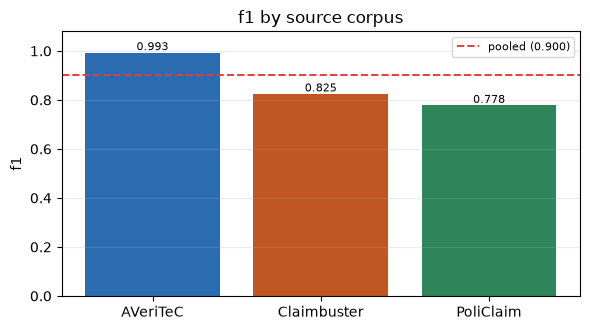

In [8]:
_, test_df = D.load_splits()
sources = D.load_sources()
test_s = D.attach_source(test_df, sources)

by_src = M.by_source(test_s, (test_p >= THRESHOLD).astype(int))
P.by_source_bars(by_src, metric='f1', name='by_source_f1');
by_src


## Out-of-distribution detection

If the model degrades on unfamiliar text, it would be useful to know when text is
unfamiliar. Mahalanobis distance measures how far a sentence's pooled embedding sits
from the mean of the training embeddings.

AUROC of 0.5 means the distance carries no information about whether a sentence is
in-domain or not.


AUROC 0.4736   detector size 4.72 MB


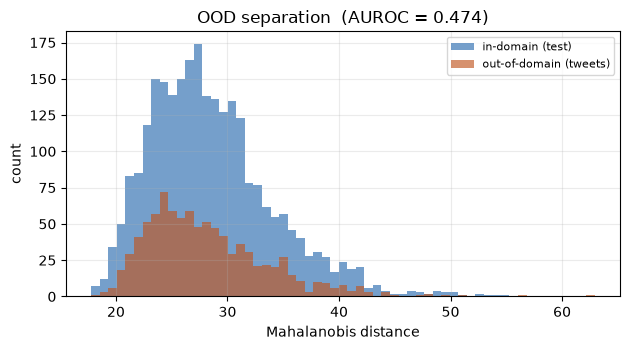

In [9]:
det = OOD.Mahalanobis().fit(fit_em)

d_in, d_out = det.score(test_em), det.score(ood_em)
auroc = OOD.separation_auroc(d_in, d_out)

P.ood_separation(d_in, d_out, auroc, name='ood_separation');
print(f'AUROC {auroc:.4f}   detector size {det.nbytes()/1e6:.2f} MB')
